In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import math

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

data_dir = Path("/content/drive/MyDrive/ml in med")

train_labels_data = data_dir / "training_set_pixel_size_and_HC.csv"
test_pixels_data = data_dir / "test_set_pixel_size.csv"

train_dir = data_dir / "training_set"
test_dir  = data_dir / "test_set"

In [9]:
train_df = pd.read_csv(train_labels_data)
test_df  = pd.read_csv(test_pixels_data)

print("Train labels CSV shape:", train_df.shape)
display(train_df.head())

print("\nTrain numeric summary:")
display(train_df[["pixel size(mm)", "head circumference (mm)"]].describe())

print("\nTest pixels CSV shape:", test_df.shape)
display(test_df.head())


Train labels CSV shape: (999, 3)


,filename,pixel size(mm),head circumference (mm)
0,000_HC.png,0.069136,44.30
1,001_HC.png,0.089659,56.81
2,002_HC.png,0.062033,68.75
3,003_HC.png,0.091291,69.00
4,004_HC.png,0.061240,59.81



Train numeric summary:


,pixel size(mm),head circumference (mm)
count,999.000000,999.000000
mean,0.139846,174.383093
std,0.053005,65.282061
min,0.049415,44.300000
25%,0.108801,153.600000
50%,0.128357,174.060000
75%,0.157678,189.825000
max,0.393280,346.400000



Test pixels CSV shape: (335, 2)


,filename,pixel size(mm)
0,000_HC.png,0.235857
1,001_HC.png,0.067973
2,002_HC.png,0.165202
3,003_HC.png,0.096674
4,004_HC.png,0.202203


In [10]:
def list_ultrasound_images(root: Path):
    pngs = sorted(root.rglob("*.png"))
    # keep only ultrasound images; annotations usually contain 'Annotation' in filename
    imgs = [p for p in pngs if "Annotation" not in p.name]
    return imgs

train_images = list_ultrasound_images(train_dir)
test_images  = list_ultrasound_images(test_dir)

print("Training ultrasound images:", len(train_images))
print("Test ultrasound images    :", len(test_images))
print("Example train image:", train_images[0] if train_images else "NONE")
print("Example test image :", test_images[0] if test_images else "NONE")


Training ultrasound images: 999
Test ultrasound images    : 335
Example train image: /content/drive/MyDrive/ml in med/training_set/training_set/000_HC.png
Example test image : /content/drive/MyDrive/ml in med/test_set/test_set/000_HC.png


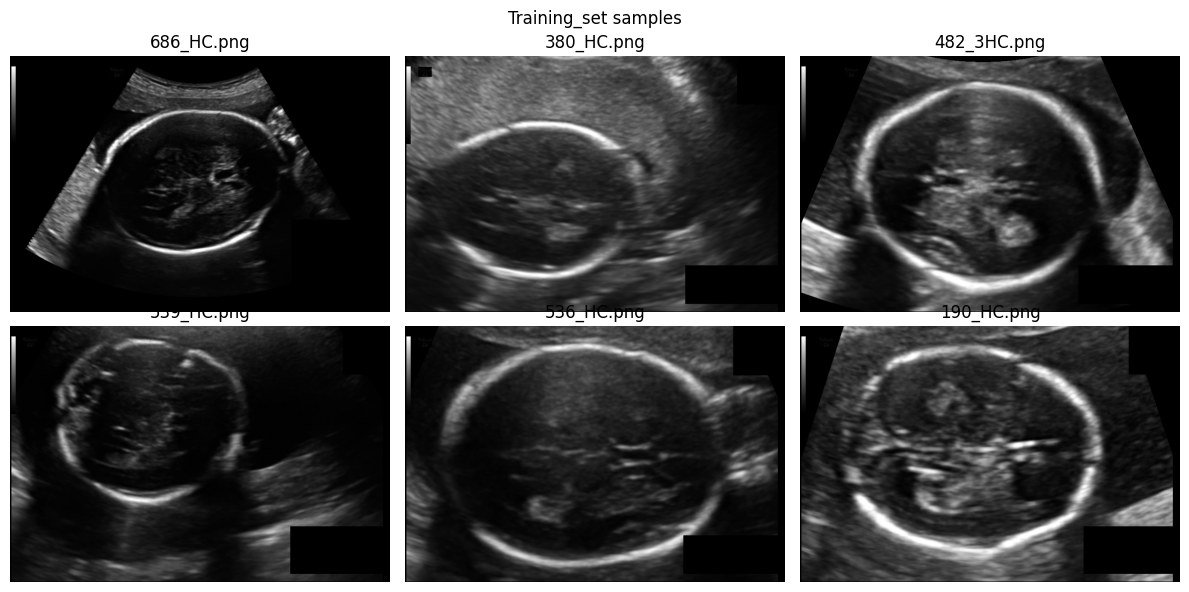

In [13]:
def show_samples(paths, k=6, title="Samples"):
    k = min(k, len(paths))
    picks = random.sample(paths, k)
    plt.figure(figsize=(12, 6))
    for i, p in enumerate(picks, 1):
        img = Image.open(p).convert("L")
        plt.subplot(2, math.ceil(k/2), i)
        plt.imshow(img, cmap="gray")
        plt.title(p.name)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_images, k=6, title="Training_set samples")

In [14]:
train_name_to_path = {p.name: p for p in train_images}
test_name_to_path  = {p.name: p for p in test_images}

# Keep only rows where filename exists in extracted images
train_df2 = train_df[train_df["filename"].isin(train_name_to_path.keys())].copy()
print("Train rows matched to images:", len(train_df2), "/", len(train_df))

# Split training_set into train/val for MAE evaluation
tr_df, val_df = train_test_split(train_df2, test_size=0.2, random_state=42)
print("Train split:", len(tr_df), " Val split:", len(val_df))

Train rows matched to images: 999 / 999
Train split: 799  Val split: 200


In [15]:
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # grayscale -> 3 channels
    transforms.Normalize(mean=EfficientNet_B0_Weights.DEFAULT.transforms().mean,
                         std=EfficientNet_B0_Weights.DEFAULT.transforms().std),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=EfficientNet_B0_Weights.DEFAULT.transforms().mean,
                         std=EfficientNet_B0_Weights.DEFAULT.transforms().std),
])

class HC18TrainDataset(Dataset):
    def __init__(self, frame, tfms, name_to_path):
        self.frame = frame.reset_index(drop=True)
        self.tfms = tfms
        self.name_to_path = name_to_path

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img_path = self.name_to_path[row["filename"]]
        y = float(row["head circumference (mm)"])
        img = Image.open(img_path).convert("L")
        x = self.tfms(img)
        return x, torch.tensor([y], dtype=torch.float32)

train_ds = HC18TrainDataset(tr_df, train_tfms, train_name_to_path)
val_ds   = HC18TrainDataset(val_df, val_tfms,   train_name_to_path)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print("Loaders ready:", len(train_ds), "train,", len(val_ds), "val")


Loaders ready: 799 train, 200 val


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)  # regression output
model = model.to(device)

loss_fn = nn.L1Loss()  # MAE loss
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

best_path = data_dir / "best_efficientnet_hc18.pt"

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 86.2MB/s]


In [22]:
@torch.no_grad()
def evaluate_mae(model, loader):
    model.eval()
    maes = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        maes.append(torch.mean(torch.abs(pred - y)).item())
    return float(np.mean(maes))

def train_one_epoch(model, loader):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)

train_mae_hist = []
val_mae_hist = []

best_val = float("inf")
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    tr_mae = train_one_epoch(model, train_loader)
    val_mae = evaluate_mae(model, val_loader)

    train_mae_hist.append(tr_mae)
    val_mae_hist.append(val_mae)

    print(f"Epoch {epoch:02d} | train_MAE(mm)={tr_mae:.3f} | val_MAE(mm)={val_mae:.3f}")

    if val_mae < best_val:
        best_val = val_mae
        torch.save(model.state_dict(), best_path)

print("\nBest validation MAE (mm):", best_val)
print("Saved model:", best_path)



Epoch 01 | train_MAE(mm)=102.454 | val_MAE(mm)=98.043
Epoch 02 | train_MAE(mm)=98.816 | val_MAE(mm)=92.514
Epoch 03 | train_MAE(mm)=95.660 | val_MAE(mm)=90.783
Epoch 04 | train_MAE(mm)=92.117 | val_MAE(mm)=90.709
Epoch 05 | train_MAE(mm)=89.008 | val_MAE(mm)=89.634
Epoch 06 | train_MAE(mm)=85.333 | val_MAE(mm)=76.982
Epoch 07 | train_MAE(mm)=82.011 | val_MAE(mm)=73.705
Epoch 08 | train_MAE(mm)=78.431 | val_MAE(mm)=72.242
Epoch 09 | train_MAE(mm)=75.014 | val_MAE(mm)=69.270
Epoch 10 | train_MAE(mm)=71.507 | val_MAE(mm)=61.288

Best validation MAE (mm): 61.28795887873723
Saved model: /content/drive/MyDrive/ml in med/best_efficientnet_hc18.pt


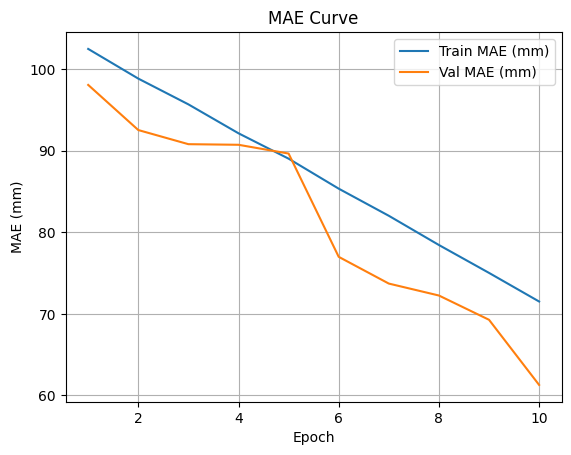

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_mae_hist) + 1)

plt.figure()
plt.plot(epochs, train_mae_hist, label="Train MAE (mm)")
plt.plot(epochs, val_mae_hist, label="Val MAE (mm)")
plt.xlabel("Epoch")
plt.ylabel("MAE (mm)")
plt.title("MAE Curve")
plt.legend()
plt.grid(True)
plt.show()
